Problem 1: Max Subarray Problem
Recall the max subarray problem presented in class. We used divide and conquer method to derive a  Θ(𝑛log(𝑛))
  worst case time algorithm to solve it.

In this assignment, we would like you to solve this problem in  Θ(𝑛)
  time. I.e, your algorithm should be able to compute the result by just iterating through the array and keeping track of some quantities.

Let [a0, a1,....,ak] be a python array (list) of size k + 1. Here is the idea:

As we iterate index i from 0 to k (inclusive), track a quantity minSoFar that is the minimum of the array so far from 0 to i-1. Initialize minSoFar to +infinity (In python you can say float('inf') to get a number that represents  ∞
 ).
Consider the difference a[i] - minSoFar. Calculate the maximum such difference when iterating over the entire array.
Convince yourself that this will yield the overall solution to the max subarray problem with a complexity of  Θ(𝑛)


self note - this is basically stock prices given and you have one day to buy another day to sell. what is max profit?

In [1]:
def maxSubArray(a):
    n = len(a)
    if n == 1:
        return 0
    minSoFar = float('inf')
    maxProfit = 0
    for i in range(n):
        if(a[i] < minSoFar):
            minSoFar = a[i]
        if(a[i] - minSoFar > maxProfit):
            maxProfit = a[i] - minSoFar
    return maxProfit

In [2]:
from random import randint

assert(maxSubArray([100, -2, 5, 10, 11, -4, 15, 9, 18, -2, 21, -11]) == 25), 'Test 1 failed'
assert(maxSubArray([-5, 1, 10, 4, 11, 4, 15, 9, 18, 0, 21, -11]) == 26), 'Test 2 failed'
assert(maxSubArray([26, 0, 5, 18, 11, -1, 15, 9, 13, 5, 16, -11]) == 18), 'Test 3 failed'

def get_random_array(n):
    assert(n > 100)
    lst = [randint(0, 25) for j in range(n)]
    lst[0] = 1000
    lst[10] = -15
    lst[25] = 40
    lst[n-10] = 60
    lst[n-3]= -40
    return lst
assert(maxSubArray(get_random_array(50000)) == 75), 'Test on large random array 50000 failed'
assert(maxSubArray(get_random_array(500000)) == 75), 'Test on large random array of size 500000 failed'
print('All tests passed (10 points!)')

All tests passed (10 points!)


Problem 2
We studied polynomial multiplication using FFT in class. Recall the algorithm given two polynomials  𝑎(𝑥)=𝑎0+𝑎1𝑥+⋯+𝑎𝑛−1𝑥𝑛−1
  and  𝑏(𝑥)=𝑏0+𝑏1𝑥+⋯+𝑏𝑚−1𝑥𝑚−1
 .

Pad the coefficients of  𝑎,𝑏
  with zero coefficients to make up two polynomials of degree  𝑚+𝑛−2
  (expected size of the result).
Compute FFTs of  [𝑎0,…,𝑎𝑛−1,0,…,0]
  and  [𝑏0,…,𝑏𝑛−1,0,…,0]
 .
Let  [𝐴0,…,𝐴𝑚+𝑛−2]
  and  [𝐵0,…,𝐵𝑚+𝑛−2]
  be the resulting FFT sequences.
Multiply the FFT sequences:  [𝐴0×𝐵0,…,𝐴𝑚+𝑛−2×𝐵𝑚+𝑛−2]
 .
Compute the inverse FFT to obtain the polynomial  𝑐(𝑥)=𝑎(𝑥)𝑏(𝑥)
 .
First implement polynomial multiplication using FFT. For convenience, please use the numpy package in python which implements functions numpy.fft.fft and numpy.fft.ifft. The advantages include efficient computation of FFT for sizes of inputs that are not powers of two.

Brief Illustration of Numpy fft and ifft functions.

In [3]:
from numpy.fft import fft, ifft
from numpy import real, imag

#fft --> computes fft of a list or numpy array
#ifft -> computes inverse fft of list or numpy array

# Create a list
lst0 = [1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1]
# Compute its fft
fft_lst0 = fft(lst0)
print(f'FFT of {lst0} is\n \t {fft_lst0}' )
# Compute iverse fft
ifft_lst0 = ifft(fft_lst0)
print(f'After ifft: {ifft_lst0}' )
# Check that all the imaginary parts are tiny in the ifft result
# Note that they will not be zero due to floating point error
assert(all([abs(imag(x))<= 1E-10 for x in ifft_lst0])), 'Something went wrong -- we should not have complex parts to the ifft result'
# Extract the real parts
print('Note that we can suppress the vanishingly small complex cofficients')
fix_ifft_lst0 = [real(x) for x in ifft_lst0]
print(f'After converting back to float: {fix_ifft_lst0}')

FFT of [1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1] is
 	 [ 0.00000000e+00+0.00000000e+00j  2.22044605e-16+1.11022302e-16j
  0.00000000e+00+0.00000000e+00j  1.11022302e-16+2.42822736e-16j
  0.00000000e+00+0.00000000e+00j -2.22044605e-16+1.91772697e-16j
  0.00000000e+00+0.00000000e+00j  1.40000000e+01-3.68609473e-18j
  0.00000000e+00+0.00000000e+00j  0.00000000e+00-1.96369182e-16j
  0.00000000e+00+0.00000000e+00j  6.66133815e-16-2.41182270e-16j
  0.00000000e+00+0.00000000e+00j  5.55111512e-16-1.04380189e-16j]
After ifft: [ 1.-8.80425117e-34j -1.-6.04575824e-17j  1.-2.03413264e-17j
 -1.+9.24706324e-19j  1.+9.24706324e-19j -1.-2.03413264e-17j
  1.-6.23006298e-17j -1.+0.00000000e+00j  1.+6.04575824e-17j
 -1.+2.03413264e-17j  1.-9.24706324e-19j -1.-9.24706324e-19j
  1.+2.03413264e-17j -1.+6.23006298e-17j]
Note that we can suppress the vanishingly small complex cofficients
After converting back to float: [np.float64(1.0), np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1

Implement the polynomial_multiply function below.

In [42]:
from numpy.fft import fft, ifft
from numpy import real, imag, pad

def polynomial_multiply(a_coeff_list, b_coeff_list):
    # Return the coefficient list of the multiplication 
    # of the two polynomials 
    # Returned list must be a list of floating point numbers.
    # Please convert list from complex to reals by using the 
    # real function in numpy.
    # your code here
    n = len(a_coeff_list)
    m = len(b_coeff_list)
    len_c = n + m - 1
    # a_coeff_list = pad(a_coeff_list, (0, len_c - n), 'constant')
    # b_coeff_list = pad(b_coeff_list, (0, len_c - m), 'constant')
    a_coeff_padded =  a_coeff_list + [0] * (len_c - n)
    b_coeff_padded =  b_coeff_list + [0] * (len_c - m)
    # print('a_coeff_list = ', a_coeff_list)
    # print('b_coeff_list = ', b_coeff_list)
    fft_a = fft(a_coeff_padded)
    fft_b = fft(b_coeff_padded)
    fft_c = [ fft_a[x] * fft_b[x] for x in range(len_c)]
    poly_c = ifft(fft_c)
    poly_c_real = [real(x) for x in poly_c]
    # print('poly_c_real=', poly_c_real)
    return poly_c_real


In [43]:
def check_poly(lst1, lst2):
    print(f'Your code found: {lst1}')
    print(f'Expected: {lst2}')
    assert(len(lst1) == len(lst2)), 'Lists have different lengths'
    for (k,j) in zip(lst1, lst2):
        assert abs(k-j)<= 1E-05, 'Polynomials do not match'
    print('Passed!')
print('-------') 
print('Test # 1')
# multiply (1 + x - x^3) with (2 - x + x^2)
a = [1, 1, 0, -1]
b = [2, -1, 1]
c = polynomial_multiply(a,b)
assert(len(c) == 6)
print(f'c={c}')
check_poly(c, [2,1,0,-1,1,-1])
print('-------')
print('Test # 2')
# multiply 1 - x + x^2 + 2 x^3 + 3 x^5 with 
#            -x^2 + x^4 + x^6
a = [1, -1, 1, 2, 0, 3]
b = [0, 0, -1, 0, 1, 0, 1]
c = polynomial_multiply(a,b)
assert(len(c) == 12)
print(f'c={c}')
check_poly(c, [0, 0, -1, 1, 0, -3, 2, -2, 1, 5, 0, 3])
print('-------')
print('Test # 3')
# multiply 1 - 2x^3 + x^7 - 11 x^11
# with     2 - x^4 - x^6 + x^8
a = [1, 0, 0, -2, 0, 0, 0, 1, 0, 0, 0, -11]
b = [2, 0, 0, 0, -1, 0, -1, 0, 1]
c = polynomial_multiply(a, b)
assert(len(c) == 20)
print(f'c={c}')
check_poly(c, [2, 0, 0, -4, -1, 0, -1, 4, 1, 2, 0, -25, 0, -1, 0, 12, 0, 11, 0, -11])
print('All tests passed (10 points!)')

-------
Test # 1
c=[np.float64(2.0), np.float64(1.0), np.float64(7.401486830834377e-17), np.float64(-1.0), np.float64(1.0), np.float64(-0.9999999999999998)]
Your code found: [np.float64(2.0), np.float64(1.0), np.float64(7.401486830834377e-17), np.float64(-1.0), np.float64(1.0), np.float64(-0.9999999999999998)]
Expected: [2, 1, 0, -1, 1, -1]
Passed!
-------
Test # 2
c=[np.float64(1.4802973661668753e-16), np.float64(2.9605947323337506e-16), np.float64(-0.9999999999999997), np.float64(1.0), np.float64(2.9605947323337506e-16), np.float64(-3.0), np.float64(2.0), np.float64(-1.9999999999999996), np.float64(0.9999999999999997), np.float64(5.0), np.float64(-4.440892098500626e-16), np.float64(3.0)]
Your code found: [np.float64(1.4802973661668753e-16), np.float64(2.9605947323337506e-16), np.float64(-0.9999999999999997), np.float64(1.0), np.float64(2.9605947323337506e-16), np.float64(-3.0), np.float64(2.0), np.float64(-1.9999999999999996), np.float64(0.9999999999999997), np.float64(5.0), np.float

Problem 3
We are given three subsets of numbers  𝐴,𝐵,𝐶⊆{0,…,𝑛}
 . Design an algorithm that runs in worst case time  Θ(𝑛log(𝑛))
  that checks if there exists numbers  𝑛1,𝑛2
  in  𝐴,𝐵
 , respectively and number  𝑛3
  in  𝐶
  such that  𝑛1+𝑛2=𝑛3
 .

Hint: Convert the set  𝐴={𝑛0,𝑛1,…,𝑛𝑘}
  into the polynomial  𝑝𝐴(𝑥): 𝑥 power 𝑛0+𝑥 power 𝑛1+⋯+𝑥 power 𝑛𝑘 
 . Suppose  𝑝𝐴(𝑥),𝑝𝐵(𝑥)
  are polynomials obtained from the sets  𝐴,𝐵
  respectively, interpret what the product  𝑝𝐴(𝑥)×𝑝𝐵(𝑥)
  signifies. Use this to complete an algorithm for the problem at hand that runs in  𝑛log(𝑛)
  time.

In [54]:
# inputs sets a, b, c
# return True if there exist n1 in a, n2 in B such that n1+n2 in C
# return False otherwise
# number n which signifies the maximum number in a, b, c
# here is a useful reference to set data structure in python
# https://docs.python.org/3/tutorial/datastructures.html#sets
def check_sum_exists(a, b, c, n):
    a_coeffs = [0]*n
    b_coeffs = [0]*n 
    # convert sets a, b into polynomials as provided in the hint
    # a_coeffs and b_coeffs should contain the result
    # your code here
    for k in a:
        a_coeffs[k] = 1 
    for k in b:
        b_coeffs[k] = 1 
    
    # multiply them together
    c_coeffs = polynomial_multiply(a_coeffs, b_coeffs)
    coeffs_copy = []
    for num in c_coeffs: # code given by example
        if(abs(num-0) < abs(num-1)):
            coeffs_copy.append(0)
        elif(abs(num-1) < abs(num-2)):
            coeffs_copy.append(1)
        else:
            coeffs_copy.append(2)
    # use the result to solve the problem at hand
    # your code here
    for num in c:
        if(c_coeffs[num] >= 0.5 ):
            return True
    return False
    # return True/False

In [55]:
print('-- Test 1 --')
a = set([1, 2, 10, 11])
b = set([2, 5, 8, 10])
c = set([1, 2, 5,  8])
assert not check_sum_exists(a, b, c, 12), f'Failed Test 1: your code returned true when the expected answer is false'
print('Passed')
print('-- Test 2 --')
a = set([1, 2, 10, 11])
b = set([2, 5, 8, 10])
c = set([1, 2, 5,  8, 11])
assert check_sum_exists(a, b, c, 12), f'Failed Test 2: your code returns false but note that 1 in a + 10 in b = 11 in c '
print('Passed')

print('-- Test 3 --')
a={1, 4, 5, 7, 11, 13, 14, 15, 17, 19, 22, 23, 24, 28, 34, 35, 37, 39, 42, 44}
b={0, 1, 4, 9, 10, 11, 12, 15, 18, 20, 25, 31, 34, 36, 38, 40, 43, 44, 47, 49}
c={3, 4, 5, 7, 8, 10, 19, 20, 21, 24, 31, 35, 36, 37, 38, 39, 42, 44, 46, 49}
assert check_sum_exists(a, b, c, 50), f'Failed Test 3: your code returns False whereas the correct answer is true eg., 4 + 0 = 4'

print('-- Test 4 --')

a={98, 2, 99, 40, 77, 79, 87, 88, 89, 27}
b={64, 66, 35, 69, 70, 40, 76, 45, 12, 60}
c={36, 70, 10, 44, 15, 16, 83, 20, 84, 55}
assert not check_sum_exists(a, b, c, 100), f'Failed Test 4: your code returns True whereas the correct answer is False'

print('All Tests Passed (15 points)!')

-- Test 1 --
Passed
-- Test 2 --
Passed
-- Test 3 --
-- Test 4 --
All Tests Passed (15 points)!


Problem 4
We have given a file called natural_gas_futures_weekly_all.csv which is weekly data for natural gas futures from 8/2000 to 5/2021.

For your convenience, the code below opens the CSV file and for each week. Note that as a data scientist you should familiarize yourself with libraries such as Pandas. Currently, we will keep things simple and process the data using the csv package in python.

The code below will create a list of weekly prices in the python variable weekly_prices.

In [56]:
import csv
from matplotlib import pyplot as plt

file = open('natural_gas_futures_weekly_all.csv','r')
csv_handle = csv.DictReader(file)

weekly_prices = []
dates = []

for rows in csv_handle:
    dates.append(rows['Date'])
    weekly_prices.append(0.5 * (float(rows['High']) + float(rows['Low'])) )
file.close()

plt.plot(range(len(weekly_prices)), weekly_prices, '-b')
plt.xlabel('Week #')
plt.ylabel('Crude Oil Future Price')

FileNotFoundError: [Errno 2] No such file or directory: 'natural_gas_futures_weekly_all.csv'

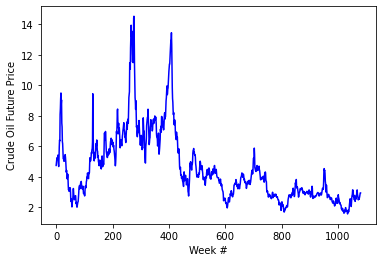

Problem 1: Max Subarray Problem
Recall the max subarray problem presented in class. We used divide and conquer method to derive a  Θ(𝑛log(𝑛))
  worst case time algorithm to solve it.

In this assignment, we would like you to solve this problem in  Θ(𝑛)
  time. I.e, your algorithm should be able to compute the result by just iterating through the array and keeping track of some quantities.

Let [a0, a1,....,ak] be a python array (list) of size k + 1. Here is the idea:

As we iterate index i from 0 to k (inclusive), track a quantity minSoFar that is the minimum of the array so far from 0 to i-1. Initialize minSoFar to +infinity (In python you can say float('inf') to get a number that represents  ∞
 ).
Consider the difference a[i] - minSoFar. Calculate the maximum such difference when iterating over the entire array.
Convince yourself that this will yield the overall solution to the max subarray problem with a complexity of  Θ(𝑛)


self note - this is basically stock prices given and you have one day to buy another day to sell. what is max profit?

Note that the rate at which the data is provided is 1 data item per week. The data ranges over a period of 1081 weeks (~ 20 years).

First we compute the fast fourier transform of the data using numpy.fft.fft function. Note that length of fft is also 1081. Let the fft be stored in list fft_data.

Second, create a list called frequencies that has the frequency corresponding to each element in the fft_data. Remember that the data's time period is 1 week. We will represent all frequencies in the unit  week−1
 .

Using a combination of the numpy.fft.fft and numpy.fft.ifft functions, please extract the low frequency components of the signal that correspond to frequencies in the range [0, 1/52 weeks], [1/52 weeks, 1/13 weeks] and the high frequency terms greater than or equal to 1/13 weeks.

The resulting lists should be called : upto_1_year, one_year_to_1_quarter and less_than_1_quarter respectively.

In [57]:
from numpy.fft import fft, ifft, fftfreq
from numpy import real,imag

# here we have computed the fft of the weekly_prices
fft_data =  fft(weekly_prices)
N = len(fft_data)
assert(N == len(weekly_prices))

# TODO: first fill in the frequencies call this list 
# fft_frequencies -- it must have length N
fft_frequencies = [i / N for i in range(N)] # where after (N//2)+1 till N-1 they have to be assigned negative values
for i in range(N//2 + 1, N):
    fft_frequencies[i] -= 1
# it must store the frequencies of each element in the fft_data
# ensure that the frequencies of the second half are negative.
# your code here
assert all( abs(imag(x)) <= 1E-10 for x in range((N//2)+1,N))
       
# This function will be useful for you. Please go through the code.

def select_all_items_in_freq_range(lo, hi):
    # TODO: go through the fft_data and select only those frequencies in the range lo/hi
    new_fft_data = [] # make sure we have the 0 frequency component
    for (fft_val, fft_freq) in zip(fft_data, fft_frequencies): # zip creates list of tuples with corresponding elements of 2 lists
        if lo <= fft_freq and fft_freq < hi:
            new_fft_data.append(fft_val)
        elif -hi < fft_freq and fft_freq <= -lo: #even negative frequencies are considered is absolute is within the range
            new_fft_data.append(fft_val)
        else:
            new_fft_data.append(0.0)
    filtered_data = ifft(new_fft_data) # appeneded fft's in  the given freq range and inverse fft'ed
    assert all( abs(imag(x)) <= 1E-10 for x in filtered_data)
    return [real(x) for x in filtered_data]

upto_1_year = [] # All signal components with frequency < 1/52
one_year_to_1_quarter = [] # All signal components with frequency between 1/52 (inclusive) and 1/13 weeks (not inclusive)
less_than_1_quarter = [] # All signal components with frequency >= 1/13 

# TODO: Redefine the three lists using the select_all_items function
# your code here
upto_1_year = select_all_items_in_freq_range(0, 1/52)
one_year_to_1_quarter = select_all_items_in_freq_range(1/52, 1/13)
less_than_1_quarter = select_all_items_in_freq_range(1/13, 1) # highest frequency is every week since data sampling is per week

NameError: name 'weekly_prices' is not defined

In [58]:
from matplotlib import pyplot as plt
plt.plot(upto_1_year,'-b',lw=2)
plt.plot(weekly_prices,'--r',lw=0.2)
plt.xlabel('Week #')
plt.ylabel('Price')
plt.title('Frequency components < once/year')
plt.figure()
plt.plot(one_year_to_1_quarter,'-b',lw=2)
plt.plot(weekly_prices,'--r',lw=0.2)
plt.title('Frequency components between once/year and once/quarter')
plt.xlabel('Week #')
plt.ylabel('Price')
plt.figure()
plt.plot(less_than_1_quarter,'-b',lw=2)
plt.plot(weekly_prices,'--r',lw=0.2)
plt.title('Frequency components >  once/quarter')
plt.xlabel('Week #')
plt.ylabel('Price')

plt.figure()
plt.plot([(v1 + v2 + v3) for (v1, v2, v3) in zip(upto_1_year,one_year_to_1_quarter,less_than_1_quarter)],'-b',lw=2)
plt.plot(weekly_prices,'--r',lw=0.2)
plt.title('Sum of all the components')
plt.xlabel('Week #')
plt.ylabel('Prices')

N = len(weekly_prices)
assert(len(fft_frequencies) == len(weekly_prices))
assert(fft_frequencies[0] == 0.0)
assert(abs(fft_frequencies[N//2] - 0.5 ) <= 0.05), f'fft frequncies incorrect: {fft_frequencies[N//2]} does not equal 0.5'
assert(abs(fft_frequencies[N//4] - 0.25 ) <= 0.05), f'fft frequncies incorrect:  {fft_frequencies[N//4]} does not equal 0.25'
assert(abs(fft_frequencies[3*N//4] + 0.25 ) <= 0.05), f'fft frequncies incorrect:  {fft_frequencies[3*N//4]} does not equal -0.25'
assert(abs(fft_frequencies[1] - 1/N ) <= 0.05), f'fft frequncies incorrect:  {fft_frequencies[1]} does not equal {1/N}'
assert(abs(fft_frequencies[N-1] + 1/N ) <= 0.05), f'fft frequncies incorrect:  {fft_frequencies[N-1]} does not equal {-1/N}'

for (v1, v2, v3, v4) in zip(weekly_prices, upto_1_year,one_year_to_1_quarter,less_than_1_quarter ):
    assert ( abs(v1 - (v2 + v3+v4)) <= 0.01), 'The components are not adding up -- there is a mistake in the way you split your original signal into various components'
print('All tests OK -- 10 points!!')

NameError: name 'upto_1_year' is not defined

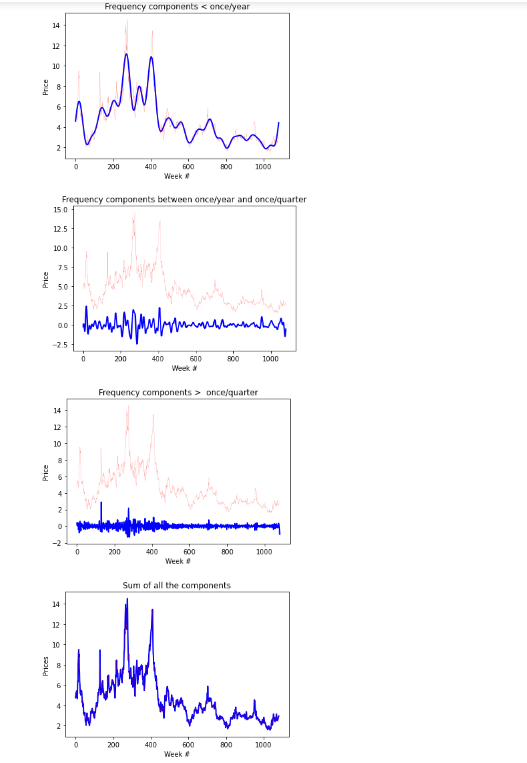